# HIV Classifier Colab Wrapper

This notebook wraps the modular project in this repository (`hiv_classifier/`) and runs it step-by-step.

You can edit settings in one place and keep model/data/training code in package modules.

In [1]:
# Colab/kernel-safe dependency install
import importlib.util
import subprocess
import sys

def _install(packages):
    if not packages:
        return
    subprocess.check_call([sys.executable, "-m", "pip", "install", *packages])

core_packages = ["numpy", "matplotlib", "scikit-learn", "pyyaml", "torch", "rdkit"]
optional_packages = ["deepchem"]

# Install core dependencies required by the notebook and package modules.
missing_core = [pkg for pkg in core_packages if importlib.util.find_spec(pkg.split("-")[0]) is None]
if missing_core:
    print("Installing core packages:", missing_core)
    _install(missing_core)
else:
    print("Core packages already available.")

# DeepChem is optional now; loader has a CSV fallback if this cannot install.
missing_optional = [pkg for pkg in optional_packages if importlib.util.find_spec(pkg) is None]
if missing_optional:
    try:
        print("Attempting optional install:", missing_optional)
        _install(missing_optional)
    except Exception as exc:
        print("Optional dependency install failed. Continuing with fallback loader.")
        print("Details:", exc)
else:
    print("Optional packages already available.")

Installing core packages: ['scikit-learn', 'pyyaml']
Optional packages already available.


In [ ]:
# Project path setup
import os
import sys
from pathlib import Path

# Auto-detect repo root. Works whether you open the notebook from the repo root
# or from inside the notebooks/ subfolder.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "hiv_classifier").exists():
    # Opened from notebooks/ subfolder — walk up one level
    if (PROJECT_ROOT.parent / "hiv_classifier").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent
    else:
        # Colab: update this to match where you cloned the repo on Drive
        fallback = Path('/content/drive/MyDrive/hiv-inhibition-classifier')
        if fallback.exists():
            PROJECT_ROOT = fallback

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('Using project root:', PROJECT_ROOT)
assert (PROJECT_ROOT / 'hiv_classifier').exists(), 'Could not find hiv_classifier package folder.'

Using project root: c:\Users\elbak\Desktop\Classes\Chem\ChemProject


In [3]:
# Imports from your modular code
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from hiv_classifier.utils import set_seed, get_device, ensure_dir
from hiv_classifier.data import load_hiv_smiles_and_labels, smiles_to_morgan, split_data, build_dataloaders
from hiv_classifier.model import HIVMLP
from hiv_classifier.train import compute_pos_weight, train_model, run_one_epoch
from hiv_classifier.evaluate import collect_probabilities_and_labels, compute_roc_metrics, plot_loss_curves, plot_roc_curve

In [4]:
# ===== Editable experiment settings (single place to tune) =====
CFG = {
    'seed': 42,
    'device': 'auto',
    'data': {
        'fingerprint_bits': 1024,
        'fingerprint_radius': 2,
        'train_ratio': 0.8,
        'val_ratio': 0.1,
        'test_ratio': 0.1,
        'batch_size_train': 256,
        'batch_size_eval': 512,
        'num_workers': 2
    },
    'model': {
        'input_dim': 1024,
        'hidden_dim_1': 512,
        'hidden_dim_2': 256,
        'dropout': 0.5
    },
    'training': {
        'epochs': 50,
        'learning_rate': 1e-3
    },
    'results_dir': 'results'
}

set_seed(CFG['seed'])
device = get_device(CFG['device'])
ensure_dir(CFG['results_dir'])
print('Device:', device)

Device: cpu


In [5]:
# 1) Load MoleculeNet HIV labels and SMILES
smiles, labels = load_hiv_smiles_and_labels()
print('Labeled molecules loaded:', len(labels))

# 2) Convert SMILES to Morgan fingerprints
X, y, stats = smiles_to_morgan(
    smiles=smiles,
    labels=labels,
    radius=CFG['data']['fingerprint_radius'],
    n_bits=CFG['data']['fingerprint_bits']
)
print('Fingerprint conversion stats:', stats)
print('Feature shape:', X.shape, 'Label shape:', y.shape)

Labeled molecules loaded: 41127


[13:13:42] DEPRECATION WARNING: please use MorganGenerator
[13:13:42] DEPRECATION WARNING: please use MorganGenerator
[13:13:42] DEPRECATION WARNING: please use MorganGenerator
[13:13:42] DEPRECATION WARNING: please use MorganGenerator
[13:13:42] DEPRECATION WARNING: please use MorganGenerator
[13:13:42] DEPRECATION WARNING: please use MorganGenerator
[13:13:42] DEPRECATION WARNING: please use MorganGenerator
[13:13:42] DEPRECATION WARNING: please use MorganGenerator
[13:13:42] DEPRECATION WARNING: please use MorganGenerator
[13:13:42] DEPRECATION WARNING: please use MorganGenerator
[13:13:42] DEPRECATION WARNING: please use MorganGenerator
[13:13:42] DEPRECATION WARNING: please use MorganGenerator
[13:13:42] DEPRECATION WARNING: please use MorganGenerator
[13:13:42] DEPRECATION WARNING: please use MorganGenerator
[13:13:42] DEPRECATION WARNING: please use MorganGenerator
[13:13:42] DEPRECATION WARNING: please use MorganGenerator
[13:13:42] DEPRECATION WARNING: please use MorganGenerat

Fingerprint conversion stats: {'invalid_smiles': 7, 'valid_molecules': 41120, 'total_seen': 41127}
Feature shape: (41120, 1024) Label shape: (41120,)


In [6]:
# 3) Split data and create DataLoaders
X_train, X_val, X_test, y_train, y_val, y_test = split_data(
    X=X,
    y=y,
    train_ratio=CFG['data']['train_ratio'],
    val_ratio=CFG['data']['val_ratio'],
    test_ratio=CFG['data']['test_ratio'],
    seed=CFG['seed']
)

bundle = build_dataloaders(
    X_train=X_train,
    X_val=X_val,
    X_test=X_test,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
    batch_size_train=CFG['data']['batch_size_train'],
    batch_size_eval=CFG['data']['batch_size_eval'],
    num_workers=CFG['data']['num_workers']
)

print(f'Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}')

Train: 32896 | Val: 4112 | Test: 4112


In [7]:
# 4) Build exact requested MLP + weighted BCE loss
model = HIVMLP(
    input_dim=CFG['model']['input_dim'],
    hidden_dim_1=CFG['model']['hidden_dim_1'],
    hidden_dim_2=CFG['model']['hidden_dim_2'],
    dropout=CFG['model']['dropout']
).to(device)

pos_weight_value = compute_pos_weight(y_train)
print(f'Computed pos_weight: {pos_weight_value:.4f}')

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=device)
)
optimizer = torch.optim.Adam(model.parameters(), lr=CFG['training']['learning_rate'])

Computed pos_weight: 27.4814


In [8]:
# 5) Train model and track train/validation loss
history = train_model(
    model=model,
    train_loader=bundle.train_loader,
    val_loader=bundle.val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=CFG['training']['epochs']
)

# Save checkpoint for later reuse
checkpoint_path = Path(CFG['results_dir']) / 'best_model.pth'
torch.save(model.state_dict(), checkpoint_path)
print('Checkpoint saved to:', checkpoint_path)

c:\Users\elbak\Desktop\Classes\Chem\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/50 | Train Loss: 1.1489 | Val Loss: 1.0188
Epoch 02/50 | Train Loss: 0.8907 | Val Loss: 0.9940
Epoch 03/50 | Train Loss: 0.6743 | Val Loss: 1.1061
Epoch 04/50 | Train Loss: 0.4082 | Val Loss: 1.3622
Epoch 05/50 | Train Loss: 0.2718 | Val Loss: 1.5441
Epoch 06/50 | Train Loss: 0.2034 | Val Loss: 2.0839
Epoch 07/50 | Train Loss: 0.1561 | Val Loss: 2.2764
Epoch 08/50 | Train Loss: 0.1514 | Val Loss: 2.0429
Epoch 09/50 | Train Loss: 0.1301 | Val Loss: 2.1469
Epoch 10/50 | Train Loss: 0.1182 | Val Loss: 2.3354
Epoch 11/50 | Train Loss: 0.1069 | Val Loss: 2.5055
Epoch 12/50 | Train Loss: 0.0972 | Val Loss: 2.1827
Epoch 13/50 | Train Loss: 0.0866 | Val Loss: 2.5440
Epoch 14/50 | Train Loss: 0.0815 | Val Loss: 3.0519
Epoch 15/50 | Train Loss: 0.0938 | Val Loss: 2.1981
Epoch 16/50 | Train Loss: 0.0797 | Val Loss: 2.8478
Epoch 17/50 | Train Loss: 0.0681 | Val Loss: 2.7551
Epoch 18/50 | Train Loss: 0.0642 | Val Loss: 2.9507
Epoch 19/50 | Train Loss: 0.0749 | Val Loss: 2.5736
Epoch 20/50 

Test loss: 3.3899
Test ROC-AUC: 0.7876


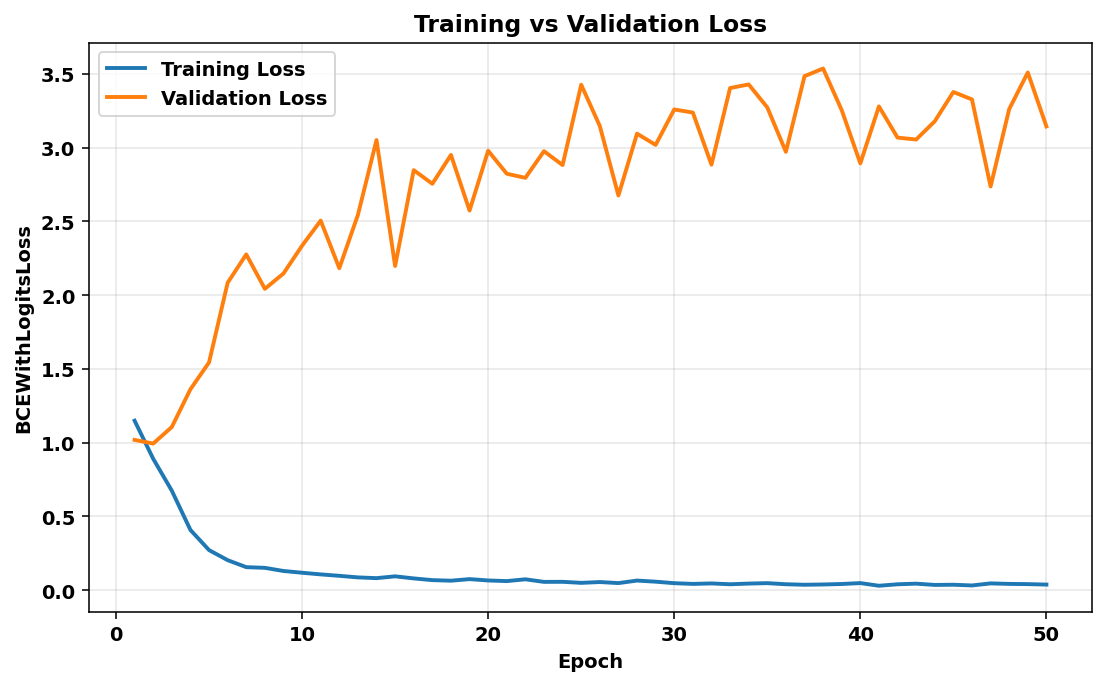

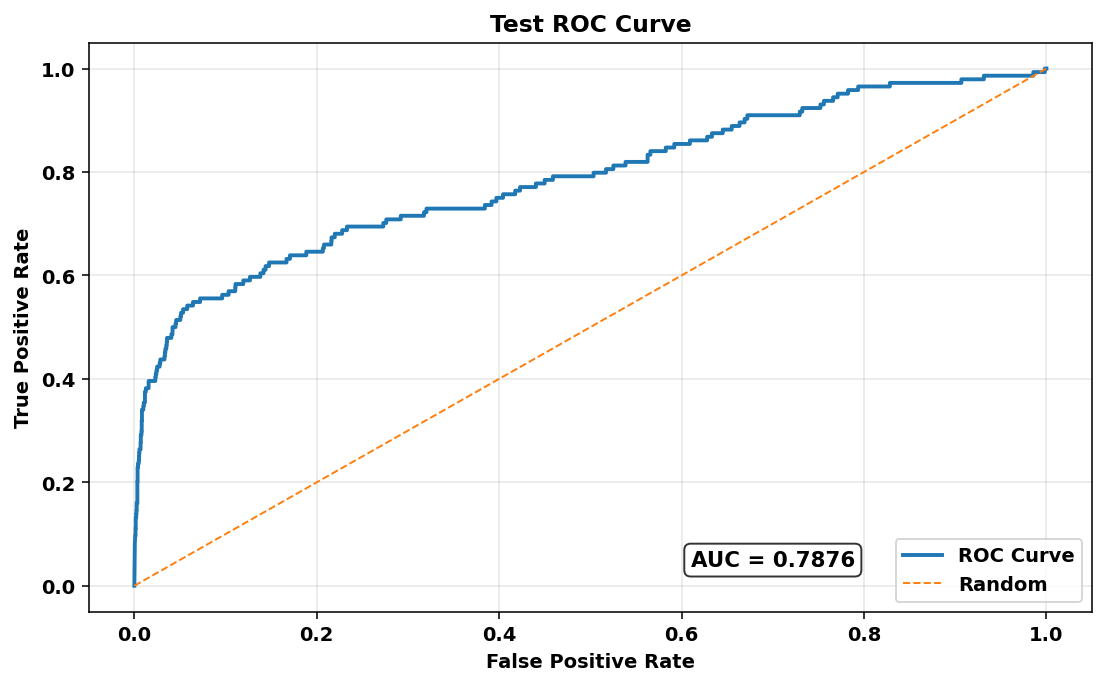

In [9]:
# 6) Evaluate on test set and draw required plots
test_loss = run_one_epoch(
    model=model,
    loader=bundle.test_loader,
    criterion=criterion,
    device=device,
    optimizer=None
)
print(f'Test loss: {test_loss:.4f}')

pred_data = collect_probabilities_and_labels(model=model, loader=bundle.test_loader, device=device)
roc_info = compute_roc_metrics(labels=pred_data['labels'], probs=pred_data['probs'])

if roc_info['auc'] is None:
    print('Test ROC-AUC: undefined (single class in test set)')
else:
    print(f"Test ROC-AUC: {roc_info['auc']:.4f}")

plot_loss_curves(
    train_losses=history['train_loss'],
    val_losses=history['val_loss'],
    save_path=str(Path(CFG['results_dir']) / 'loss_curve.png'),
    show_plot=True
)

plot_roc_curve(
    fpr=roc_info['fpr'],
    tpr=roc_info['tpr'],
    auc_value=roc_info['auc'],
    save_path=str(Path(CFG['results_dir']) / 'roc_curve.png'),
    show_plot=True
)

## Extra Metrics Section (More Result Views)

This section adds PR-AUC, precision/recall/F1, balanced accuracy, MCC, and confusion matrix plots.

Extra Metrics at threshold=0.5
PR-AUC: 0.3561
Precision: 0.3841
Recall: 0.4028
F1: 0.3932
Balanced Accuracy: 0.6897
MCC: 0.3708

Classification report:
              precision    recall  f1-score   support

           0     0.9783    0.9766    0.9774      3968
           1     0.3841    0.4028    0.3932       144

    accuracy                         0.9565      4112
   macro avg     0.6812    0.6897    0.6853      4112
weighted avg     0.9575    0.9565    0.9570      4112



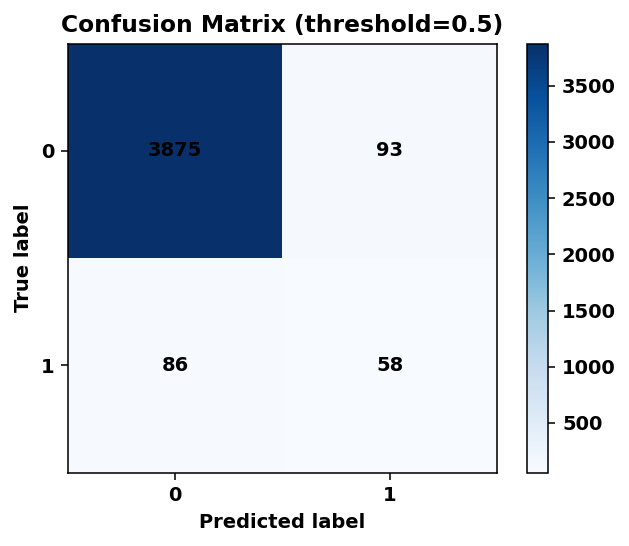

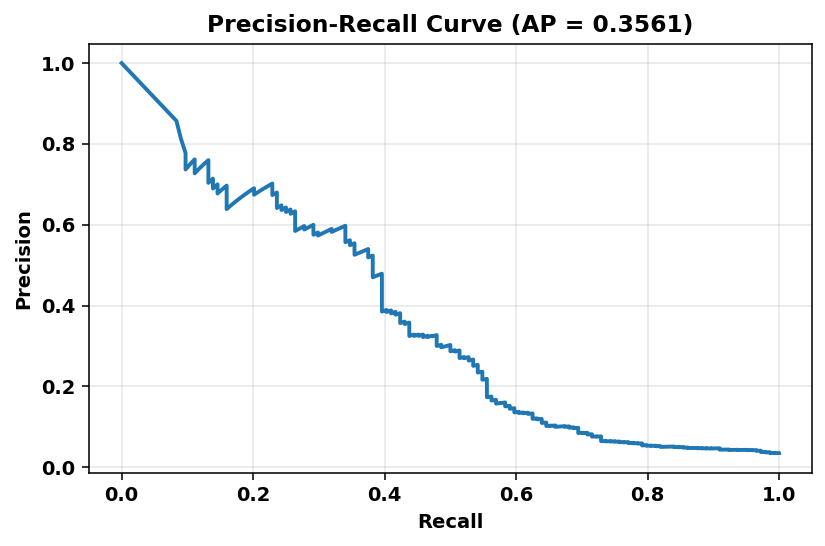

Saved extra metrics to: results\extra_metrics.json


In [10]:
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    matthews_corrcoef,
    f1_score,
    precision_score,
    recall_score
)

y_true = pred_data['labels']
y_prob = pred_data['probs']

# Default threshold for binary classification from sigmoid probabilities
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

# Core additional metrics
pr_auc = average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float('nan')
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
bal_acc = balanced_accuracy_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)

print('Extra Metrics at threshold=0.5')
print(f'PR-AUC: {pr_auc:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1: {f1:.4f}')
print(f'Balanced Accuracy: {bal_acc:.4f}')
print(f'MCC: {mcc:.4f}')

print('\nClassification report:')
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

# Confusion matrix plot
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4), dpi=140)
im = ax.imshow(cm, cmap='Blues')
ax.set_title('Confusion Matrix (threshold=0.5)')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm[i, j]), ha='center', va='center', color='black')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Precision-Recall curve
if len(np.unique(y_true)) > 1:
    p, r, _ = precision_recall_curve(y_true, y_prob)
    plt.figure(figsize=(6, 4), dpi=140)
    plt.plot(r, p, linewidth=2)
    plt.title(f'Precision-Recall Curve (AP = {pr_auc:.4f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Save all key metrics for tracking experiments
metrics_out = {
    'test_loss': float(test_loss),
    'roc_auc': None if roc_info['auc'] is None else float(roc_info['auc']),
    'pr_auc': float(pr_auc),
    'precision_at_0.5': float(precision),
    'recall_at_0.5': float(recall),
    'f1_at_0.5': float(f1),
    'balanced_accuracy_at_0.5': float(bal_acc),
    'mcc_at_0.5': float(mcc)
}
metrics_path = Path(CFG['results_dir']) / 'extra_metrics.json'
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics_out, f, indent=2)
print('Saved extra metrics to:', metrics_path)